# Student Performance Indicator

## 1) Import Data and Required Packages

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

## 2) Import the CSV data

In [3]:
df = pd.read_csv("./data/stud.csv")

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
# shape of the dataset
df.shape

(1000, 8)

In [7]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 3. Checking Values

### 3.1. Missing Values

In [8]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

### 3.2. Duplicates

In [9]:
df.duplicated().sum()

np.int64(0)

### 3.3. Data Types

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


### 3.4. Number of unique values of each column

In [11]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

## 4. Exploring data

In [15]:
list(df['gender'].unique())

['female', 'male']

In [17]:
for col in ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']:
    print(f"Categories in '{col}' variable: {list(df[col].unique())}\n")

Categories in 'gender' variable: ['female', 'male']

Categories in 'race_ethnicity' variable: ['group B', 'group C', 'group A', 'group D', 'group E']

Categories in 'parental_level_of_education' variable: ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']

Categories in 'lunch' variable: ['standard', 'free/reduced']

Categories in 'test_preparation_course' variable: ['none', 'completed']



### 4.1. Define numerical and categorical columns

In [40]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']

In [43]:
print(f"We have {len(numeric_features)} numerical features: {numeric_features}")
print(f"We have {len(categorical_features)} categorical features: {categorical_features}")

We have 3 numerical features: ['math_score', 'reading_score', 'writing_score']
We have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


### 4.2. Adding columns for "total score" and"average"

In [44]:
df['total_score'] = df["math_score"] + df["reading_score"] + df["writing_score"]
df["average"] = df["total_score"] / 3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [56]:
# count of full marks
reading_full = df[df['reading_score'] == 100]['average'].count()
writing_full = df[df['writing_score'] == 100]['average'].count()
math_full = df[df['math_score'] == 100]['average'].count()

dict_result = {
    "reading_full": reading_full,
    "writing_full": writing_full,
    "math_full": math_full
}

for i in ["reading_full", "writing_full", "math_full"]:
    print(f"Number of students with full marks in {i.split('_')[0].capitalize()}: {dict_result[i]}")


Number of students with full marks in Reading: 17
Number of students with full marks in Writing: 14
Number of students with full marks in Math: 7


In [59]:
# count of score lass than 20
reading_less_20 = df[df['reading_score'] <= 20]['average'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average'].count()
math_less_20 = df[df['math_score'] <= 20]['average'].count()

dict_result = {
    "reading": reading_less_20,
    "writing": writing_less_20,
    "math": math_less_20
}

for i in ["reading", "writing", "math"]:
    print(f"Number of students with less than 20 marks in {i.capitalize()}: {dict_result[i]}")

Number of students with less than 20 marks in Reading: 1
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Math: 4


## 5. Exploring data (Visualization)

### 5.1. Histogram & KDE

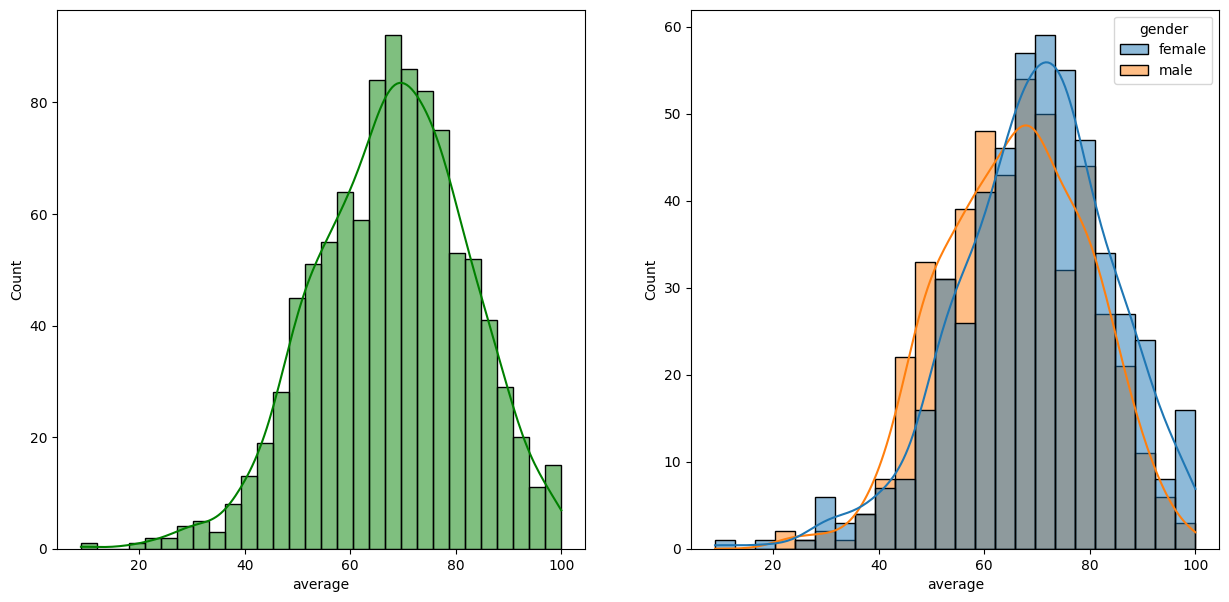

In [65]:
# Performance in relation to gender
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x='average', bins=30, kde=True, color="g")

plt.subplot(122)
sns.histplot(data=df, x="average", kde=True, hue="gender")
plt.show()

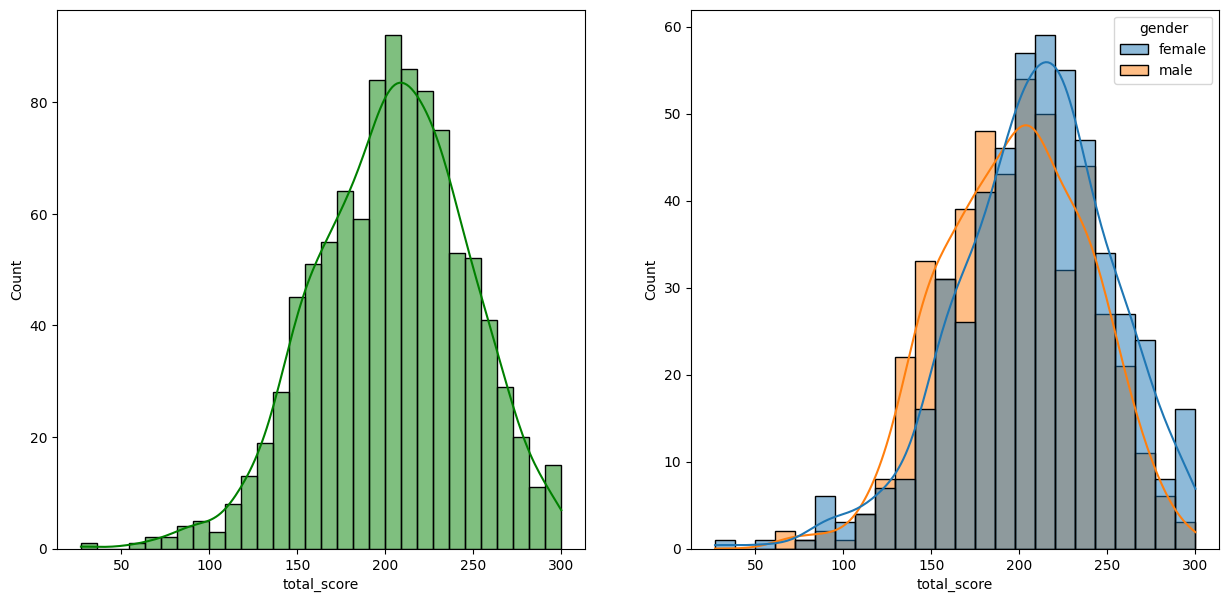

In [66]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x='total_score', bins=30, kde=True, color="g")

plt.subplot(122)
sns.histplot(data=df, x="total_score", kde=True, hue="gender")
plt.show()

#### Insights
- Female students tend to perform better than male students

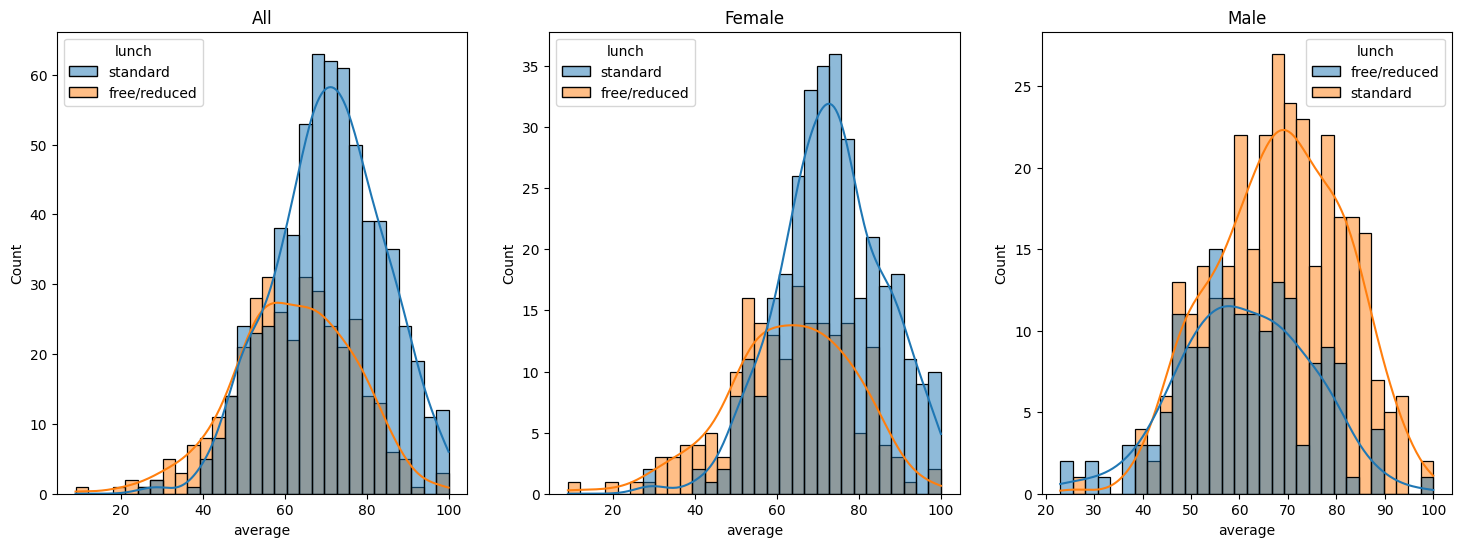

In [75]:
# Performance in relation to lunch
plt.subplots(1, 3, figsize=(18, 6))
plt.subplot(131)
sns.histplot(data=df, x="average", kde=True, hue="lunch", bins=30)
plt.title("All")

plt.subplot(132)
sns.histplot(data=df[df.gender=="female"], x="average", kde=True, hue="lunch", bins=30)
plt.title("Female")

plt.subplot(133)
sns.histplot(data=df[df.gender=="male"], x="average", kde=True, hue="lunch", bins=30)
plt.title("Male")

plt.show()

#### Insights
- Standard lunch helps perform well in exams;
- Standard lunch helps perform well in exams be it a male or a female.

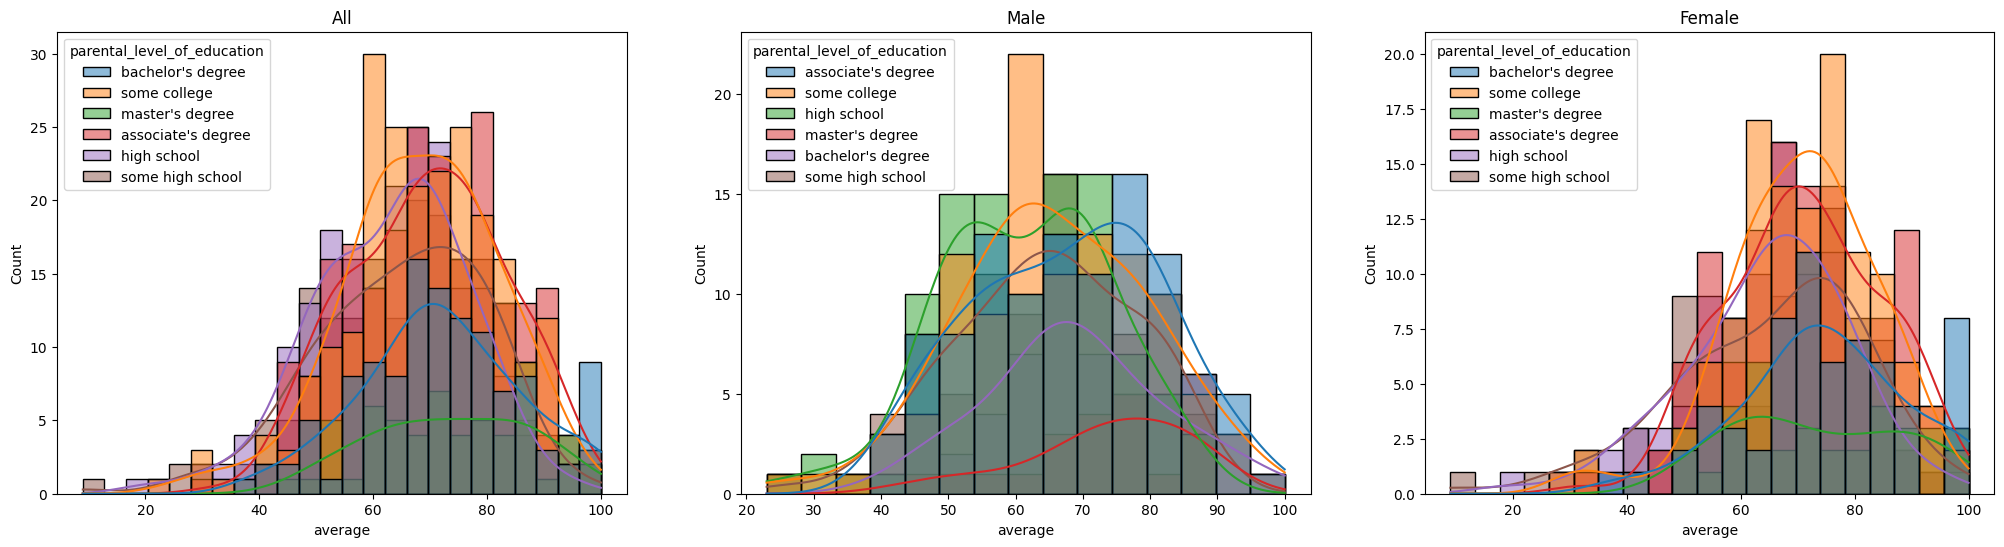

In [76]:
# Performance in relation to parental level of education
plt.subplots(1, 3, figsize=(25, 6))

plt.subplot(131)
ax= sns.histplot(data=df, x='average', kde=True, hue="parental_level_of_education")
plt.title("All")

plt.subplot(132)
ax= sns.histplot(data=df[df.gender == "male"], x='average', kde=True, hue="parental_level_of_education")
plt.title("Male")

plt.subplot(133)
ax= sns.histplot(data=df[df.gender == "female"], x='average', kde=True, hue="parental_level_of_education")
plt.title("Female")

plt.show()

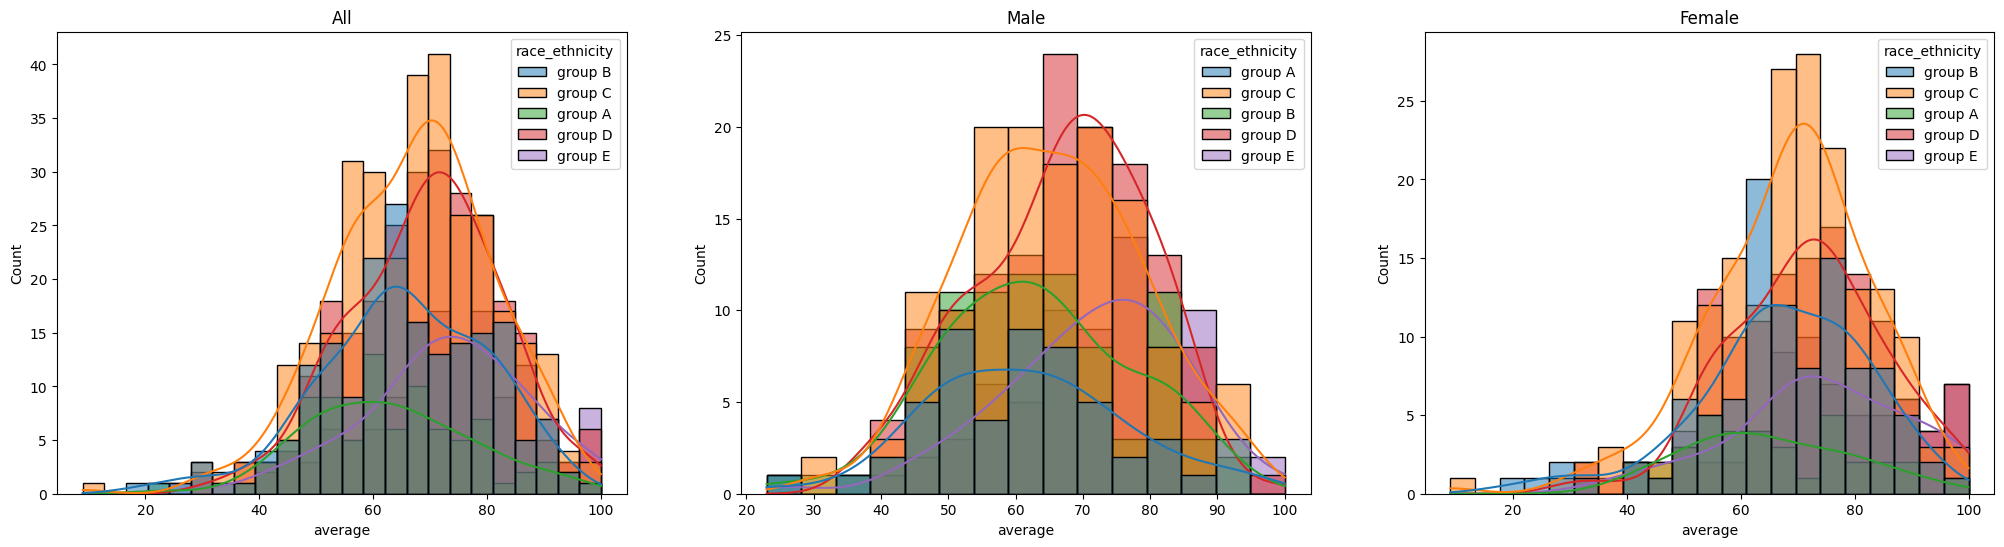

In [78]:
# Performance in relation to race/ethnicity
plt.subplots(1, 3, figsize=(25,6))

plt.subplot(131)
ax = sns.histplot(data=df, x='average', kde=True, hue='race_ethnicity')
plt.title("All")

plt.subplot(132)
ax = sns.histplot(data=df[df.gender == 'male'], x='average', kde=True, hue='race_ethnicity')
plt.title("Male")

plt.subplot(133)
ax = sns.histplot(data=df[df.gender == "female"], x='average', kde=True, hue='race_ethnicity')
plt.title("Female")

plt.show()

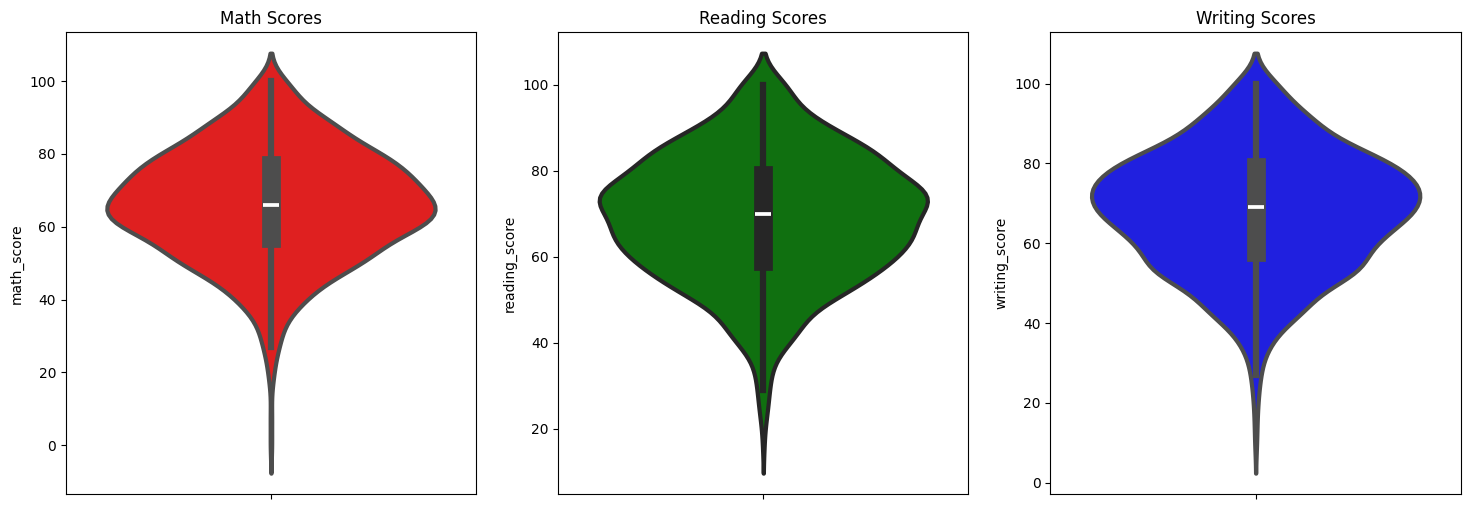

In [80]:
# Maxium score of students in all three subjects
plt.subplots(1, 3, figsize=(18,6))

plt.subplot(1, 3, 1)
plt.title('Math Scores')
sns.violinplot(data=df, y="math_score", color="red", linewidth=3)

plt.subplot(1, 3, 2)
plt.title("Reading Scores")
sns.violinplot(data=df, y="reading_score", color="green", linewidth=3)

plt.subplot(1, 3, 3)
plt.title("Writing Scores")
sns.violinplot(data=df, y="writing_score", color="blue", linewidth=3)

plt.show()

### 5.2. Gender Column

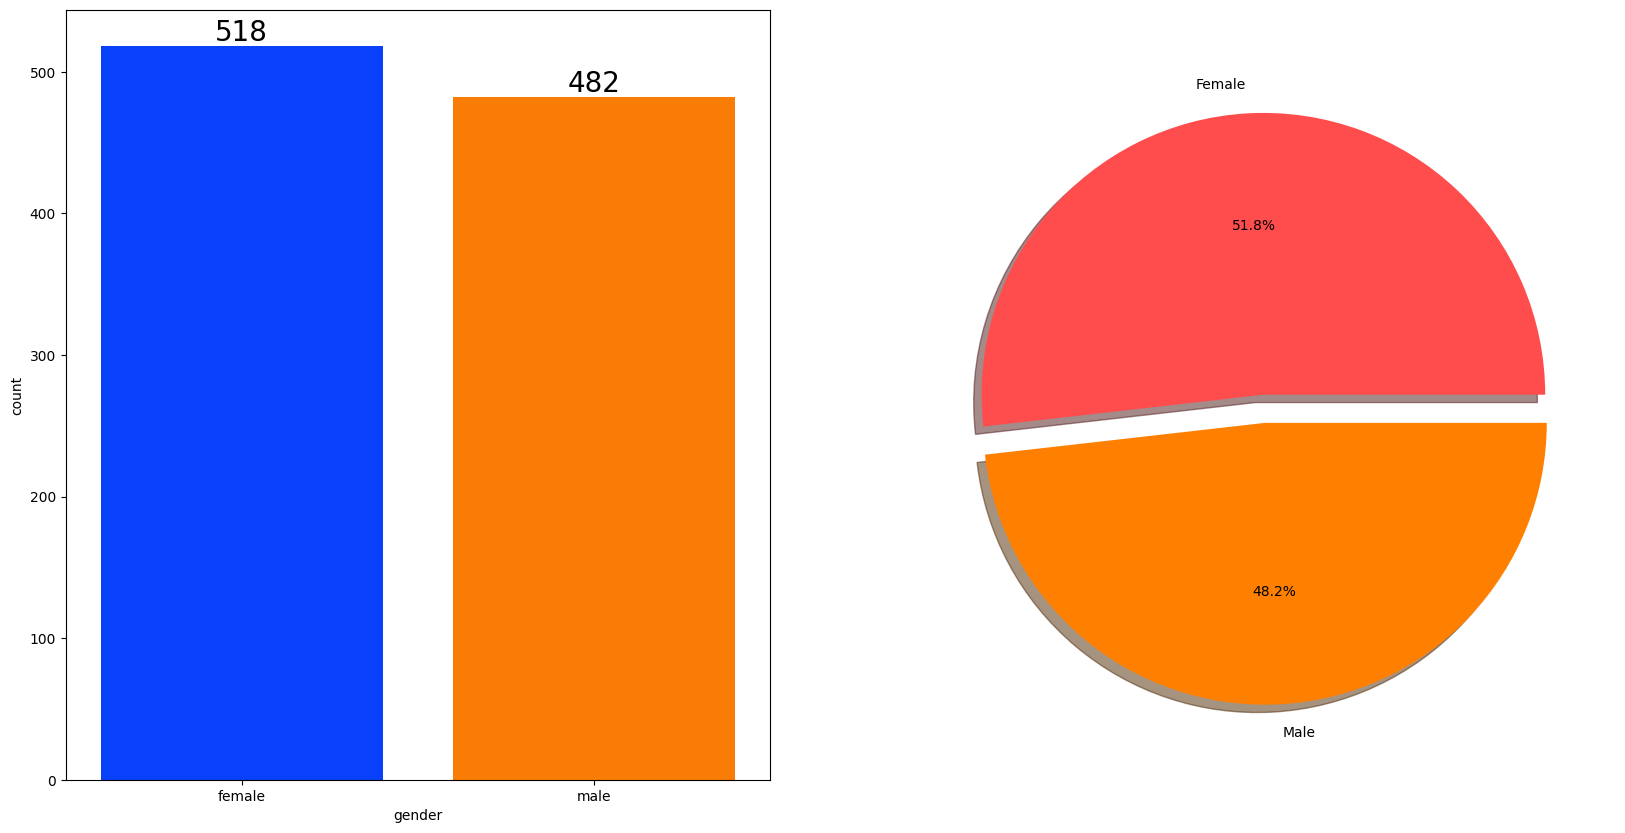

In [86]:
# univariate analysis
f, ax = plt.subplots(1,2, figsize=(20, 10))
sns.countplot(data=df, x=df['gender'], palette="bright", ax=ax[0], saturation=0.95)

for container in ax[0].containers:
    ax[0].bar_label(container, color="black", size=20)

plt.pie(x=df['gender'].value_counts(), labels=['Female', 'Male'], explode=[0, 0.1], autopct='%1.1f%%', shadow=True, colors=['#ff4d4d','#ff8000'])

plt.show()